In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import os
os.environ["OMP_NUM_THREADS"] = "5"  # Limit OpenMP
os.environ["MKL_NUM_THREADS"] = "5"  # Limit MKL (Intel Math Kernel Library)
os.environ["OPENBLAS_NUM_THREADS"] = "5"  # Limit OpenBLAS
os.environ["NUMEXPR_MAX_THREADS"] = "5"  # Limit NumExpr if installed

In [4]:
import itertools
import json
from pathlib import Path
import re
from typing import Literal

from matplotlib.colors import CenteredNorm
from matplotlib import transforms
import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
import pickle
from scipy import stats
from scipy.stats import ttest_ind, pearsonr, spearmanr
import seaborn as sns
import textgrid
import torch
from tqdm.auto import tqdm, trange
tqdm.pandas()

from src.data import get_electrode_df, add_metadata_features
from src.models.causal4 import run_causal4_analysis
from src.models import causal4
import src.viz as viz

In [5]:
sns.set_context("talk", font_scale=1.4)

In [6]:
epochs_path = "outputs/epochs_preprocessed"
tg_dir = "textgrids"

include_rois = ["superiortemporal", "postcentral", "precentral", "supramarginal", "inferiortemporal", "middletemporal",
                "parsopercularis", "caudalmiddlefrontol", "lateralorbitofrontal", "temporalpole", "inferiorparietal",
                "rostralmiddlefrontal", "parstriangularis"]

# uncorrected p-value threshold
alpha = 0.01

# ERP sources from TIMIT data
timit_epoch_sources = {
    "All": "/userdata/jgauthier/projects/ideal-word-representations/phoneme_epochs-all.h5",
    "Word onset": "/userdata/jgauthier/projects/ideal-word-representations/phoneme_epochs-onsets.h5",
}

outdir = "outputs/causal4_searchlight"

In [7]:
all_epoch_paths = list(Path(epochs_path).glob("*.fif"))

In [8]:
epochs = {}
for path in tqdm(all_epoch_paths):
    subject_name = re.findall("(EC[\d]+)_epo", str(path))[0]
    epochs[subject_name] = mne.read_epochs(str(path))
    epochs[subject_name].metadata = add_metadata_features(epochs[subject_name].metadata)

  0%|          | 0/10 [00:00<?, ?it/s]

Reading /userdata/jgauthier/projects/barakeet/outputs/epochs_preprocessed/EC278_epo.fif ...
Isotrak not found
    Found the data of interest:
        t =    -400.00 ...    2990.00 ms
        0 CTF compensation matrices available
Adding metadata with 72 columns
1152 matching events found
No baseline correction applied
0 projection items activated
Replacing existing metadata with 100 columns
Reading /userdata/jgauthier/projects/barakeet/outputs/epochs_preprocessed/EC270_epo.fif ...
Isotrak not found
    Found the data of interest:
        t =    -400.00 ...    2990.00 ms
        0 CTF compensation matrices available
Adding metadata with 72 columns
432 matching events found
No baseline correction applied
0 projection items activated
Replacing existing metadata with 100 columns
Reading /userdata/jgauthier/projects/barakeet/outputs/epochs_preprocessed/EC253_epo.fif ...
Isotrak not found
    Found the data of interest:
        t =    -400.00 ...    2990.00 ms
        0 CTF compensation matri

In [9]:
timit_bounds = viz.precompute_timit_bounds(timit_epoch_sources, epochs.keys())

  0%|          | 0/10 [00:00<?, ?it/s]

EC279 not found in /userdata/jgauthier/projects/ideal-word-representations/phoneme_epochs-all.h5
EC279 not found in /userdata/jgauthier/projects/ideal-word-representations/phoneme_epochs-onsets.h5


In [10]:
electrode_df = pd.concat([get_electrode_df(subject_name) for subject_name in epochs.keys()],
                         keys=epochs.keys(), names=["subject"])
electrode_df["roi"] = electrode_df.roi.astype(str)
electrode_df = electrode_df.droplevel("electrode_name")

# Drop electrodes metadata which don't have corresponding data
for subject, epochs_i in epochs.items():
    electrode_df.loc[subject, "keep"] = np.arange(len(electrode_df.loc[subject])) < len(epochs_i.info["ch_names"])
electrode_df = electrode_df[electrode_df["keep"]].drop(columns="keep")

electrode_df

long_name   type                         roi
subject electrode_idx                                                  
EC278   0                  Temporal1   grid              middletemporal
        1                  Temporal2   grid              middletemporal
        2                  Temporal3   grid              middletemporal
        3                  Temporal4   grid              middletemporal
        4                  Temporal5   grid              middletemporal
...                              ...    ...                         ...
EC282   217             Hippocampus6  depth  ctx_lh_S_collat_transv_ant
        218             Hippocampus7  depth  ctx_lh_S_collat_transv_ant
        219             Hippocampus8  depth  Left-Cerebral-White-Matter
        220             Hippocampus9  depth       ctx_lh_G_temporal_inf
        221            Hippocampus10  depth  Left-Cerebral-White-Matter

[2332 rows x 3 columns]

In [11]:
results = torch.load(f"{outdir}/searchlight_results.pth")
all_results_meta = results["all_results_meta"]
searchlight_results_df = results["searchlight_results_df"]
searchlight_electrode_activations = results["searchlight_electrode_activations"]
searchlight_decoder_outputs = results["searchlight_decoder_outputs"]
populations_dict = results["populations_dict"]

n_repeats = max(repeat for _, repeat in all_results_meta.keys()) + 1

/tmp/ipykernel_3773302/3253722731.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  results = torch.load(f"{outdir}/searchlight_results.pth")


In [12]:
A_df = pd.DataFrame([
    {"phoneme_pair": p["phoneme_pair"],
     "subject": p["subject"],
     "electrode_idxs": tuple(sorted(p["electrodes_a"])),
     "population": p["cluster_a"],
     "window_start": p["window_a"][0],
     "window_end": p["window_a"][1],}
    for p in populations_dict.values()])
A_df = A_df.sort_values(["subject", "phoneme_pair", "electrode_idxs"]).drop_duplicates()
A_df["name"] = A_df.subject + "_" + A_df.phoneme_pair + "_" + A_df.population.astype(str)

In [13]:
A_df.sort_values("name")

,phoneme_pair,subject,electrode_idxs,population,window_start,window_end,name
11,bm,EC243,"(87, 102)",6,0.15,0.45,EC243_bm_6
14,bm,EC250,"(238,)",6,0.15,0.45,EC250_bm_6
8,dn,EC250,"(186, 207, 216, 236)",5,0.10,0.50,EC250_dn_5
1,dn,EC253,"(3, 20, 22, 36, 37, 53, 196, 197)",0,0.10,0.55,EC253_dn_0
4,dn,EC253,"(228,)",5,0.10,0.50,EC253_dn_5
9,dn,EC260,"(204, 219, 220)",5,0.10,0.50,EC260_dn_5
7,dn,EC270,"(72,)",0,0.10,0.55,EC270_dn_0
3,dn,EC270,"(74, 118, 124)",5,0.10,0.50,EC270_dn_5
12,pb,EC270,"(64, 90, 120)",3,0.10,0.45,EC270_pb_3
6,bm,EC282,"(80, 86, 101, 105, 114, 121, 138)",3,0.10,0.60,EC282_bm_3


In [14]:
# Get one row per electrode and add ROI information
A_elecs = pd.merge(A_df.explode("electrode_idxs").rename(columns={"electrode_idxs": "electrode_idx"}),
                   electrode_df, left_on=["subject", "electrode_idx"], right_index=True, how="left")
A_elecs

,phoneme_pair,subject,electrode_idx,population,window_start,window_end,name,long_name,type,roi
11,bm,EC243,87,6,0.15,0.45,EC243_bm_6,InferiorParietal88,grid,postcentral
11,bm,EC243,102,6,0.15,0.45,EC243_bm_6,InferiorParietal103,grid,postcentral
14,bm,EC250,238,6,0.15,0.45,EC250_bm_6,Inferior111,grid,superiortemporal
8,dn,EC250,186,5,0.10,0.50,EC250_dn_5,Inferior59,grid,superiortemporal
8,dn,EC250,207,5,0.10,0.50,EC250_dn_5,Inferior80,grid,superiortemporal
8,dn,EC250,216,5,0.10,0.50,EC250_dn_5,Inferior89,grid,superiortemporal
8,dn,EC250,236,5,0.10,0.50,EC250_dn_5,Inferior109,grid,superiortemporal
1,dn,EC253,3,0,0.10,0.55,EC253_dn_0,AnteriorGrid4,grid,superiortemporal
1,dn,EC253,20,0,0.10,0.55,EC253_dn_0,AnteriorGrid21,grid,superiortemporal
1,dn,EC253,22,0,0.10,0.55,EC253_dn_0,AnteriorGrid23,grid,precentral


In [15]:
decoder_results = pd.DataFrame([
    {
        "name": "_".join(key[0]),
        "repeat": key[1],
        "subject": result.subject,
        "population_A": tuple(sorted(result.population_A)),
        "population_A_window": result.population_A_window,

        "roc_auc_val": result.phase1_val_score,
    }
    for key, result in all_results_meta.items()
])

In [16]:
decoder_results

,name,repeat,subject,population_A,population_A_window,roc_auc_val
0,EC282_dn_5,0,EC282,"(98, 99, 106)","[0.1, 0.5]",0.680990
1,EC253_dn_0,0,EC253,"(3, 20, 22, 36, 37, 53, 196, 197)","[0.1, 0.55]",0.694010
2,EC282_dn_0,0,EC282,"(117,)","[0.1, 0.55]",0.737413
3,EC270_dn_5,0,EC270,"(74, 118, 124)","[0.1, 0.5]",0.486979
4,EC253_dn_5,0,EC253,"(228,)","[0.1, 0.5]",0.606337
...,...,...,...,...,...,...
145,EC282_bm_6,9,EC282,"(68, 84, 120)","[0.15, 0.45]",0.727431
146,EC243_bm_6,9,EC243,"(87, 102)","[0.15, 0.45]",0.662326
147,EC270_pb_3,9,EC270,"(64, 90, 120)","[0.1, 0.45]",0.600260
148,EC282_pb_3,9,EC282,"(85, 102)","[0.1, 0.45]",0.534722


In [17]:
top_A = decoder_results.groupby("name").roc_auc_val.agg(["mean", "std"]).sort_values("mean", ascending=False)
top_A

,mean,std
name,,
EC250_dn_5,0.813911,0.016699
EC282_bm_6,0.713889,0.031040
EC260_dn_5,0.702387,0.009752
EC282_dn_0,0.702214,0.063555
EC282_dn_5,0.693598,0.041562
EC253_dn_0,0.683160,0.014098
EC243_bm_6,0.675944,0.019831
EC250_bm_6,0.649609,0.015120
EC282_bm_3,0.617882,0.032540


## Relationship between A decoding and resampled

In [79]:
A_df

,phoneme_pair,subject,electrode_idxs,population,window_start,window_end,name
11,bm,EC243,"(87, 102)",6,0.15,0.45,EC243_bm_6
14,bm,EC250,"(238,)",6,0.15,0.45,EC250_bm_6
8,dn,EC250,"(186, 207, 216, 236)",5,0.10,0.50,EC250_dn_5
1,dn,EC253,"(3, 20, 22, 36, 37, 53, 196, 197)",0,0.10,0.55,EC253_dn_0
4,dn,EC253,"(228,)",5,0.10,0.50,EC253_dn_5
9,dn,EC260,"(204, 219, 220)",5,0.10,0.50,EC260_dn_5
7,dn,EC270,"(72,)",0,0.10,0.55,EC270_dn_0
3,dn,EC270,"(74, 118, 124)",5,0.10,0.50,EC270_dn_5
12,pb,EC270,"(64, 90, 120)",3,0.10,0.45,EC270_pb_3
10,bm,EC282,"(68, 84, 120)",6,0.15,0.45,EC282_bm_6


In [80]:
all_decoding_resampled = []

for _, plot_row in A_df.iterrows():
    meta_key = tuple(plot_row["name"].split("_"))
    plot_meta = all_results_meta[meta_key, 0]
    p_left_phoneme = np.array([all_results_meta[meta_key, repeat].p_left_phoneme
                               for repeat in range(n_repeats)]).T.mean(axis=1)
    
    plot_metadata = plot_meta.test_trial_metadata
    assert plot_metadata.shape[0] == p_left_phoneme.shape[0], \
        f"Shape mismatch: {plot_metadata.shape} vs {p_left_phoneme.shape}"
    
    plot_metadata["p_left_phoneme"] = p_left_phoneme

    all_decoding_resampled.append(
        plot_metadata[["p_left_phoneme", "resampled", "phoneme_pair"]].assign(
            population_A=plot_row["name"]))

all_decoding_resampled = pd.concat(all_decoding_resampled, ignore_index=True)

In [231]:
all_decoding_resampled[all_decoding_resampled.population_A.str.startswith("EC253")]

,p_left_phoneme,resampled,phoneme_pair,population_A
576,0.350082,2.0,dn,EC253_dn_0
577,0.501499,5.0,dn,EC253_dn_0
578,0.256436,4.0,dn,EC253_dn_0
579,0.697620,3.0,dn,EC253_dn_0
580,0.691877,3.0,dn,EC253_dn_0
...,...,...,...,...
955,0.440883,3.0,dn,EC253_dn_5
956,0.374530,5.0,dn,EC253_dn_5
957,0.566133,2.0,dn,EC253_dn_5
958,0.585060,4.0,dn,EC253_dn_5


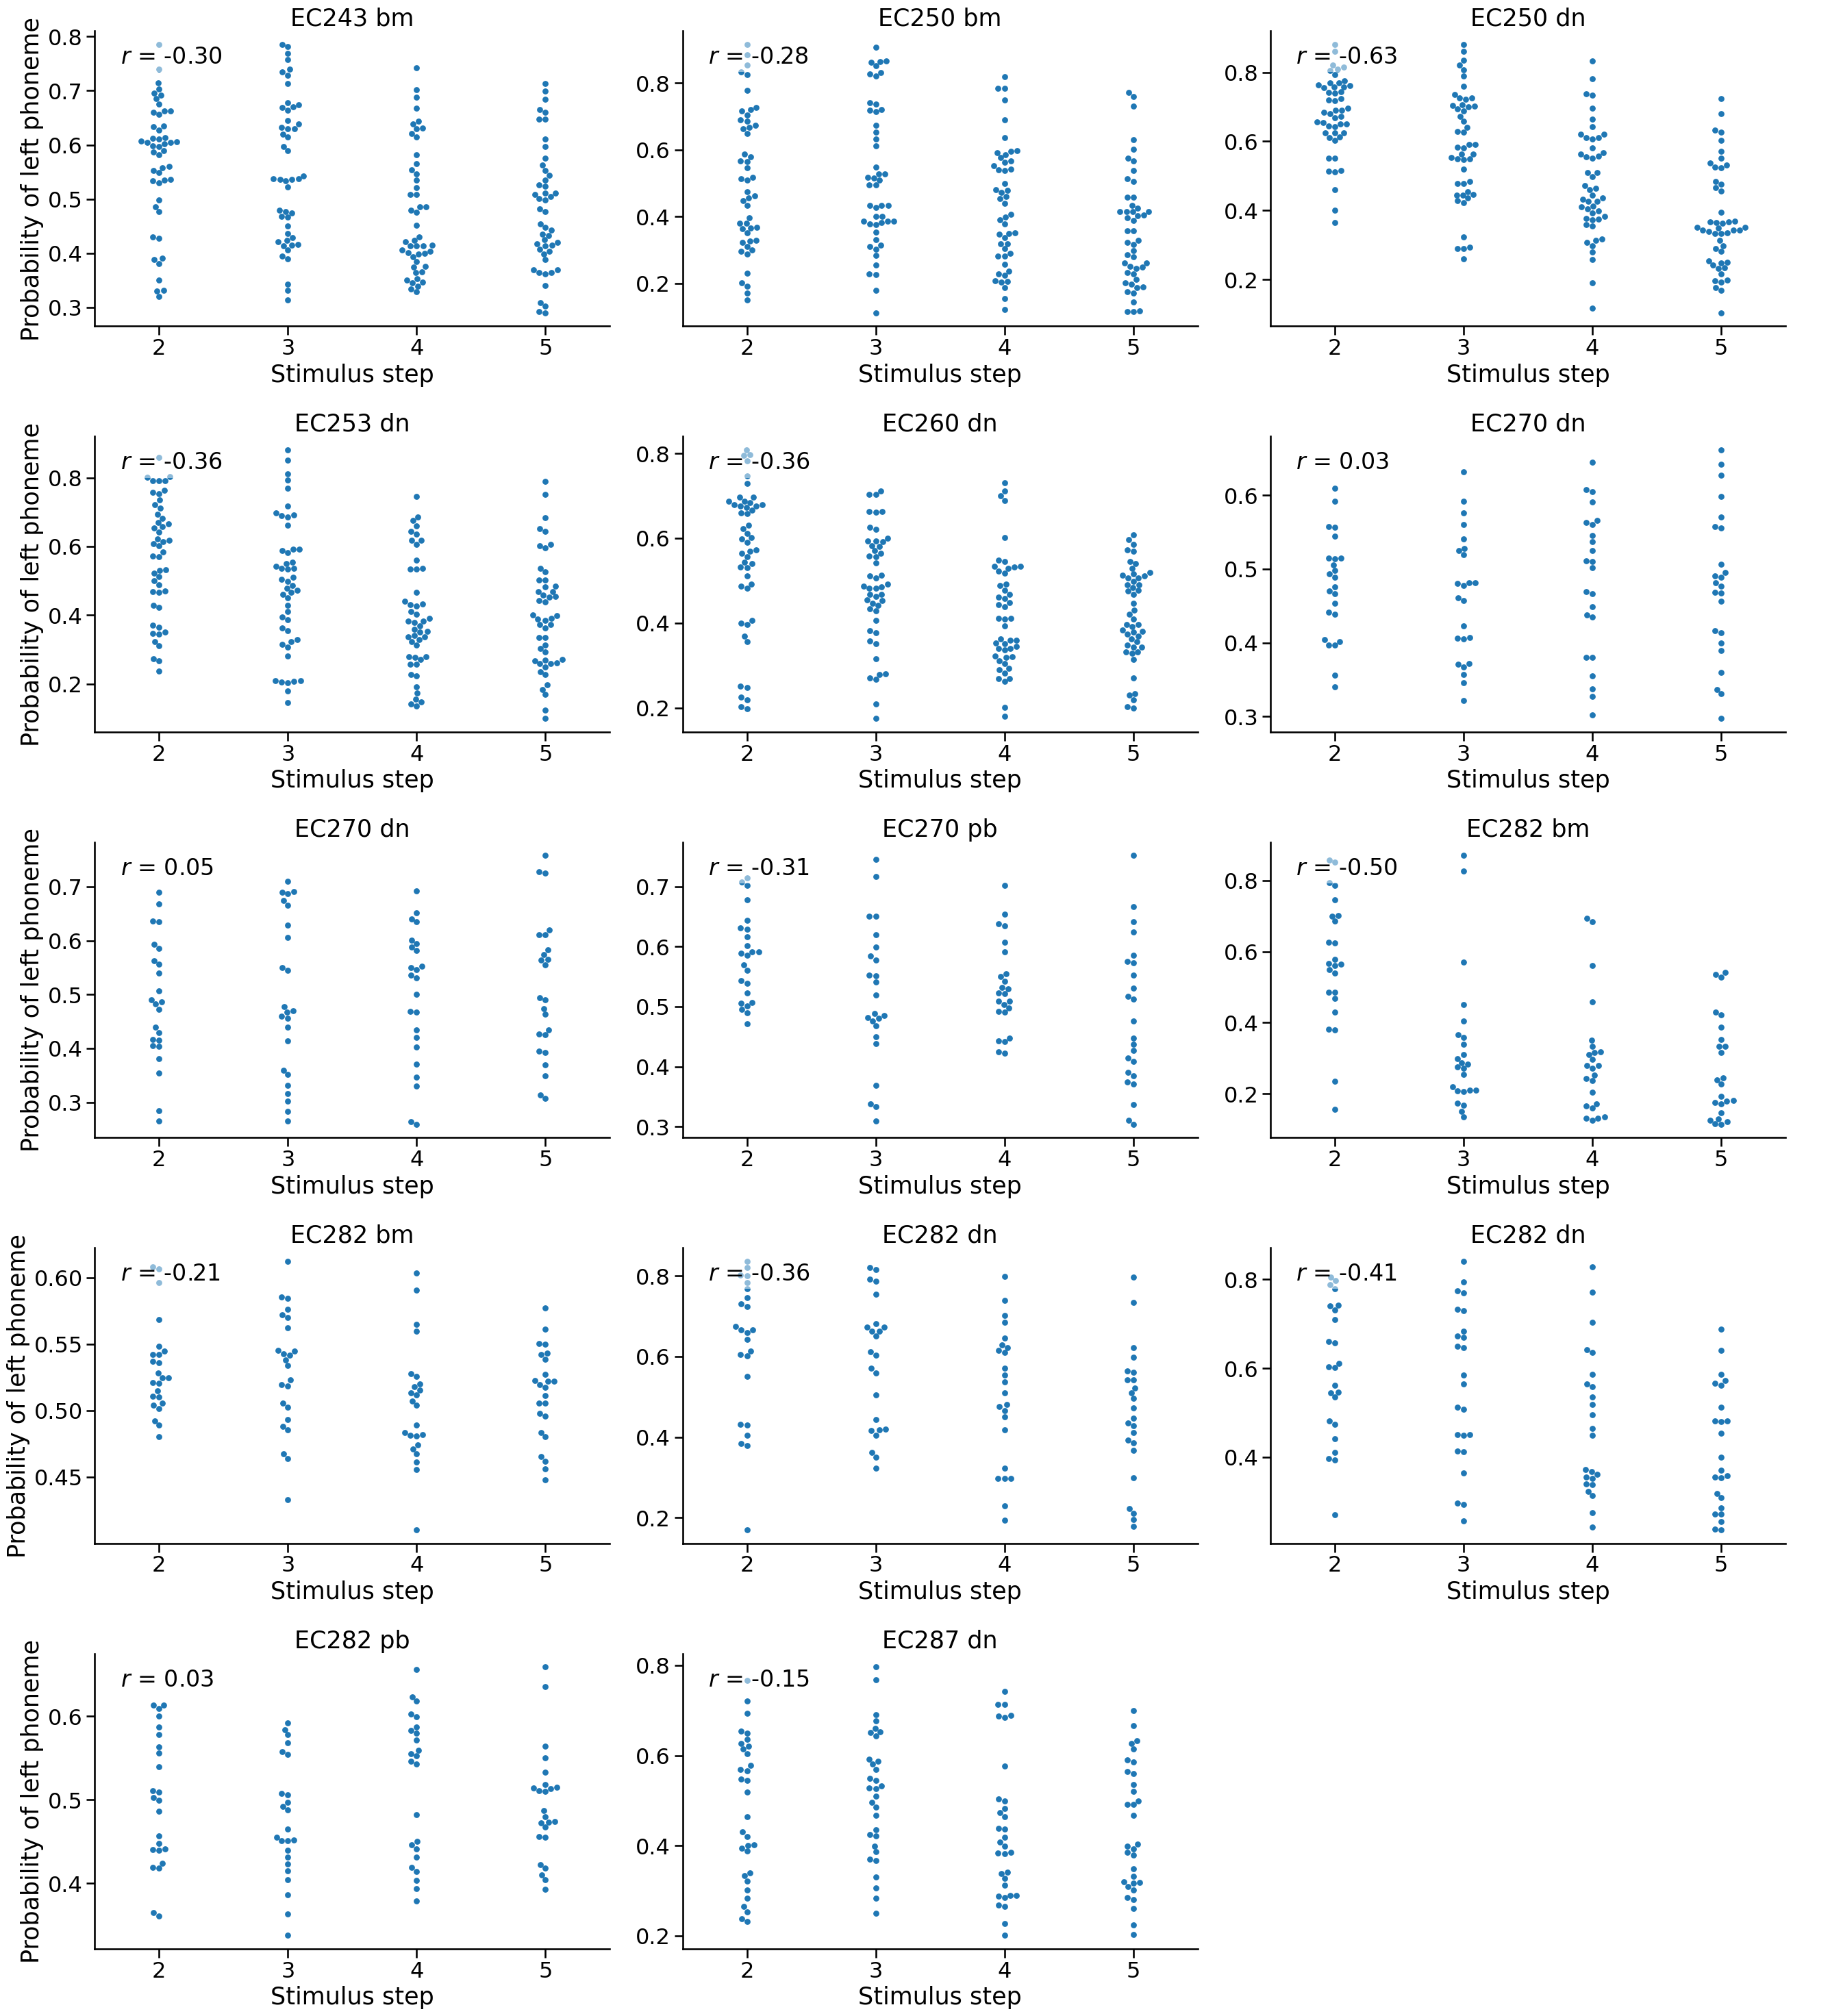

In [232]:
g = sns.catplot(data=all_decoding_resampled[all_decoding_resampled.population_A != "EC253_dn_5"].assign(resampled=lambda xs: xs.resampled.astype(int)),
                x="resampled", y="p_left_phoneme",
            col="population_A", col_wrap=3, kind="swarm", height=6, aspect=1.5, s=40,
            sharey=False, sharex=False)

def write_spearmanr(data, **kwargs):
    corr, pval = spearmanr(data["resampled"], data["p_left_phoneme"])
    ax = plt.gca()
    ax.text(0.05, 0.95, f"$r$ = {corr:.2f}",
                transform=ax.transAxes, ha="left", va="top",
                fontsize=24,
                bbox=dict(facecolor="white", alpha=0.5, edgecolor="none"))
    
    if ax.get_ylabel():
        ax.set_ylabel("Probability of left phoneme")
    ax.set_xlabel("Stimulus step")

    subject, phoneme_pair, _ = data["population_A"].iloc[0].split("_")
    ax.set_title(f"{subject} {phoneme_pair}")

g.map_dataframe(write_spearmanr)

In [103]:
decoding_resampled_correlations = all_decoding_resampled.groupby("population_A").apply(lambda xs: spearmanr(xs["resampled"], xs["p_left_phoneme"])[0])

/tmp/ipykernel_3773302/1271513759.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  decoding_resampled_correlations = all_decoding_resampled.groupby("population_A").apply(lambda xs: spearmanr(xs["resampled"], xs["p_left_phoneme"])[0])


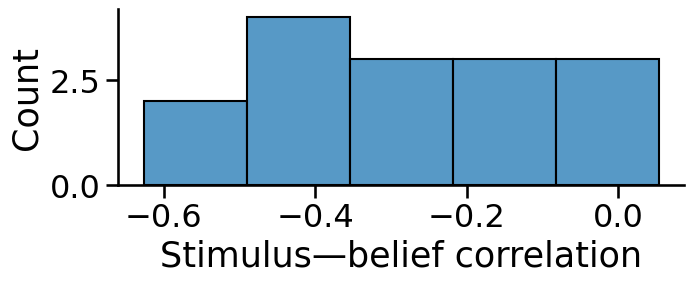

In [229]:
g = sns.displot(decoding_resampled_correlations, kind="hist", height=3, aspect=2.5)
g.set_axis_labels("Stimulus—belief correlation", "Count")

## Plot evoked

In [18]:
plot_name = "EC250_dn_5"
plot_row = decoder_results[decoder_results.name == plot_name].iloc[0]
plot_electrodes = plot_row.population_A
plot_window = plot_row.population_A_window
plot_subject, plot_phoneme_pair, plot_population_A = plot_name.split("_")

In [19]:
meta_key = (plot_subject, plot_phoneme_pair, plot_population_A)
plot_meta = all_results_meta[meta_key, 0]
p_gt_phoneme = np.array([all_results_meta[meta_key, repeat].p_gt_phoneme
                         for repeat in range(n_repeats)]).T
p_left_phoneme = np.array([all_results_meta[meta_key, repeat].p_left_phoneme
                           for repeat in range(n_repeats)]).T
plot_epoch_idxs = plot_meta.test_trial_metadata.index
plot_epochs = plot_meta.epochs
plot_metadata = plot_meta.test_trial_metadata
plot_metadata["p_gt_phoneme"] = p_gt_phoneme.mean(axis=1)
plot_metadata["p_left_phoneme"] = p_left_phoneme.mean(axis=1)

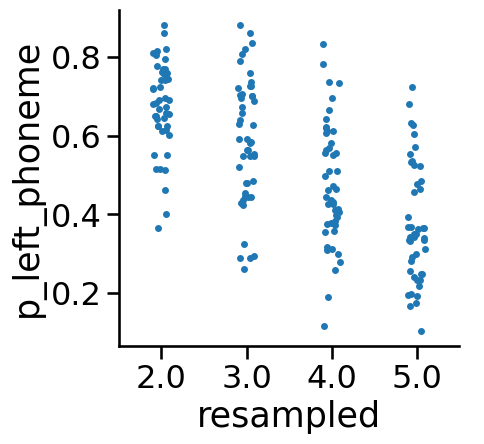

In [20]:
sns.catplot(data=plot_metadata, x="resampled", y="p_left_phoneme",)

In [18]:
epoch_times = next(iter(epochs.values())).times

/scratch/jgauthier/transformers3/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self._figure.tight_layout(*args, **kwargs)


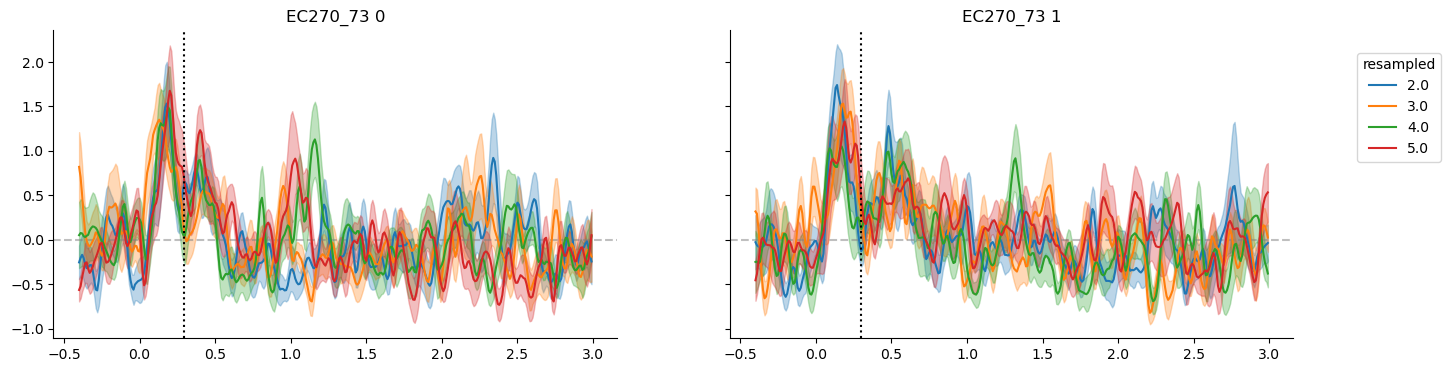

In [214]:
ep_df = plot_meta.test_trial_metadata.assign(subject=plot_subject).rename_axis("epoch_idx").reset_index()
ep_df = pd.concat([ep_df.assign(channel=el) for el in plot_electrodes]).set_index(["subject", "channel", "epoch_idx"])
ep_df["facet_label"] = ep_df.index.get_level_values("subject").str.cat(
        (ep_df.index.get_level_values("channel") + 1).astype(str), sep="_")
ep_df["resampled"] = ep_df.resampled.astype(str)
yaps = plot_epochs.get_data()
g, _, ep_df = viz.plot_epochs({(plot_subject, el): yaps[:, el, :]
                 for el in plot_electrodes},
                ep_df,
                hue="resampled",
                col="lexical_evidence",
                epoch_times=epoch_times)
# viz.add_textgrid(g, tg_dir, ep_df)

/scratch/jgauthier/transformers3/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self._figure.tight_layout(*args, **kwargs)
/scratch/jgauthier/transformers3/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self._figure.tight_layout(*args, **kwargs)


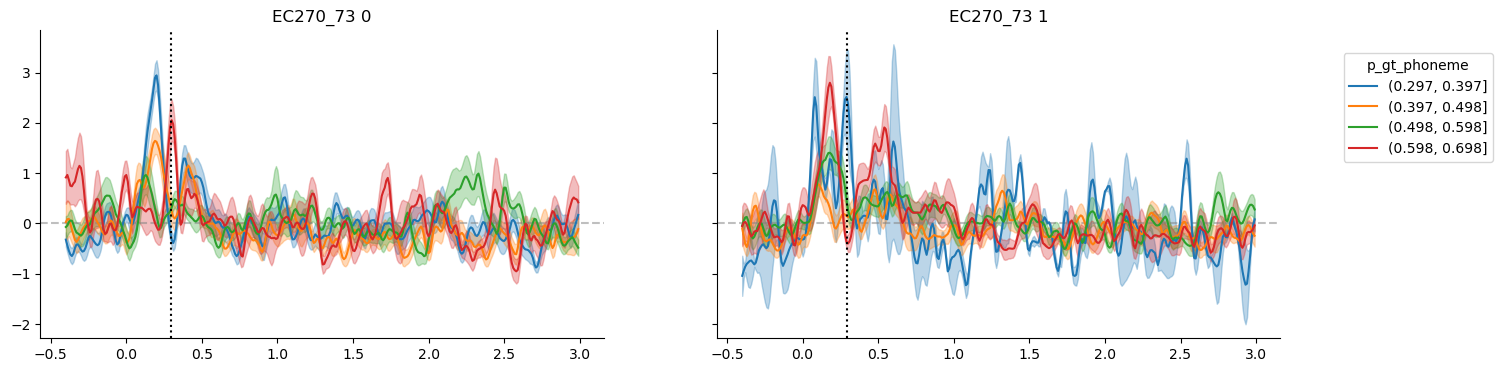

In [215]:
ep_df = plot_meta.test_trial_metadata.assign(subject=plot_subject).rename_axis("epoch_idx").reset_index()
ep_df = pd.concat([ep_df.assign(channel=el) for el in plot_electrodes]).set_index(["subject", "channel", "epoch_idx"])
ep_df["facet_label"] = ep_df.index.get_level_values("subject").str.cat(
        (ep_df.index.get_level_values("channel") + 1).astype(str), sep="_")
yaps = plot_epochs.get_data()
g, _, ep_df = viz.plot_epochs({(plot_subject, el): yaps[:, el, :]
                 for el in plot_electrodes},
                ep_df,
                hue="p_gt_phoneme",
                col="lexical_evidence",
                epoch_times=epoch_times)
# viz.add_textgrid(g, tg_dir, ep_df)

In [83]:
def plot_A_raster(subject, phoneme_pair,
                  population: str,
                  clip_zscore: tuple[float, float] = (-4, 4),
                  height: float = 4, aspect: float = 2,
                  rasterized=True,
                  crop_epochs=(-0.2, 1.0),
                  palette="plasma",
                  parameter_cache = {}):
    """
    Plot a raster of the A population for a given subject and phoneme pair.
    """
    meta_key = (subject, phoneme_pair, population)
    plot_meta = all_results_meta[meta_key, 0]
    # p_gt_phoneme = np.array([all_results_meta[meta_key, repeat].p_gt_phoneme
    #                         for repeat in range(n_repeats)]).T
    p_left_phoneme = np.array([all_results_meta[meta_key, repeat].p_left_phoneme
                                for repeat in range(n_repeats)]).T
    
    plot_metadata = plot_meta.test_trial_metadata
    # plot_metadata["p_gt_phoneme"] = p_gt_phoneme.mean(axis=1)
    plot_metadata["p_left_phoneme"] = p_left_phoneme.mean(axis=1)
    
    # sort by category, then by descending continuous value
    sort_continuous_key = "p_left_phoneme"
    plot_metadata["sort_value"] = -plot_metadata[sort_continuous_key]
    plot_raster_metadata = plot_metadata.sort_values(
        ["lexical_evidence"] + ["sort_value"],
    )

    print(subject)
    plot_raster_epochs = plot_meta.epochs[plot_raster_metadata.index]

    all_epochs = plot_meta.epochs
    plot_extreme_left_epochs = all_epochs[(all_epochs.metadata.phoneme_pair == phoneme_pair) &
                                          (all_epochs.metadata.resampled == 1)]
    plot_extreme_right_epochs = all_epochs[(all_epochs.metadata.phoneme_pair == phoneme_pair) &
                                           (all_epochs.metadata.resampled == 6)]

    # Crop
    if crop_epochs is not None:
        plot_raster_epochs = plot_raster_epochs.copy().crop(*crop_epochs)
        plot_extreme_left_epochs = plot_extreme_left_epochs.copy().crop(*crop_epochs)
        plot_extreme_right_epochs = plot_extreme_right_epochs.copy().crop(*crop_epochs)

    # TODO extract p gt phoneme

    population_electrodes = populations_dict[subject, phoneme_pair, population]["electrodes_a"]

    figs = []
    for plot_raster_channel in population_electrodes:
        plot_raster_yaps = plot_raster_epochs.get_data()[:, plot_raster_channel, :]
        plot_raster_extreme_left_yaps = plot_extreme_left_epochs.get_data()[:, plot_raster_channel, :]
        plot_raster_extreme_right_yaps = plot_extreme_right_epochs.get_data()[:, plot_raster_channel, :]

        # z-score across trials and time points
        if (subject, plot_raster_channel) not in parameter_cache:
            # cache mean and std for z-scoring
            all_epoch_data = plot_meta.epochs.copy().pick(plot_raster_channel).get_data().squeeze(1)
            hga_mean = all_epoch_data.flatten().mean()
            hga_std = all_epoch_data.flatten().std()
            parameter_cache[subject, plot_raster_channel] = (hga_mean, hga_std)
        else:
            hga_mean, hga_std = parameter_cache[subject, plot_raster_channel]

        plot_raster_yaps = (plot_raster_yaps - hga_mean) / hga_std
        plot_raster_extreme_left_yaps = (plot_raster_extreme_left_yaps - hga_mean) / hga_std
        plot_raster_extreme_right_yaps = (plot_raster_extreme_right_yaps - hga_mean) / hga_std

        # clip z-scores
        plot_raster_yaps = np.clip(plot_raster_yaps, *clip_zscore)
        plot_raster_extreme_left_yaps = np.clip(plot_raster_extreme_left_yaps, *clip_zscore)
        plot_raster_extreme_right_yaps = np.clip(plot_raster_extreme_right_yaps, *clip_zscore)

        f, ax = plt.subplots(figsize=(aspect * height, height))
        ax.set_title(f"{subject} {plot_raster_channel + 1} (part of {population}) {phoneme_pair}")

        plot_all_yaps = np.concatenate([plot_raster_extreme_left_yaps, plot_raster_yaps, plot_raster_extreme_right_yaps], axis=0)
        sns.heatmap(plot_all_yaps, rasterized=rasterized, ax=ax, cmap=palette)
        ax.set_yticks([])

        # plot a subsample of time points
        zero_idx = plot_raster_epochs.time_as_index(0)[0]
        xticks = np.linspace(zero_idx, plot_raster_yaps.shape[1] - 1, num=10, dtype=int)
        ax.set_xticks(xticks)
        ax.set_xticklabels(plot_raster_epochs.times[xticks].round(2), rotation=45)

        # create a divider for the existing axes
        from mpl_toolkits.axes_grid1 import make_axes_locatable
        divider = make_axes_locatable(ax)
        # append an axes on the left, 15% width of the heatmap ax
        ax_line = divider.append_axes("left", size="15%", pad=0.05)

        offset = 0

        extreme_left_ph = plot_extreme_left_epochs.metadata.label_acoustic.iloc[0]
        extreme_right_ph = plot_extreme_right_epochs.metadata.label_acoustic.iloc[0]

        # TODO actually plot probability values here
        left_line = ax_line.plot(np.repeat(1, len(plot_raster_extreme_left_yaps)), np.arange(offset, len(plot_raster_extreme_left_yaps)),
                     linestyle='-', label=f"extreme {extreme_left_ph}", linewidth=10)
        offset += len(plot_raster_extreme_left_yaps)

        # plot left exemplars
        left_rows = plot_raster_metadata[plot_raster_metadata.lexical_evidence_cue == -1]
        ax_line.plot(left_rows[sort_continuous_key], np.arange(offset, offset + len(left_rows)),
                     linestyle='-', label=left_rows.word_end.iloc[0], linewidth=4,
                     color=left_line[0].get_color())
        offset += len(left_rows)

        # plot right exemplars
        right_rows = plot_raster_metadata[plot_raster_metadata.lexical_evidence_cue == 1]
        right_line = ax_line.plot(right_rows[sort_continuous_key], np.arange(offset, offset + len(right_rows)),
                     linestyle='-', label=right_rows.word_end.iloc[0], linewidth=4)
        offset += len(right_rows)
        

        # plot right extremes
        ax_line.plot(np.repeat(0, len(plot_raster_extreme_right_yaps)), np.arange(offset, offset + len(plot_raster_extreme_right_yaps)),
                     linestyle='-', label=f"extreme {extreme_right_ph}", linewidth=10,
                     color=right_line[0].get_color())
        offset += len(plot_raster_extreme_right_yaps)

        ax_line.xaxis.set_label_position("top")
        ax_line.xaxis.tick_top()
        ax_line.set_ylim(len(plot_all_yaps), 0) # invert yaxis so it matches the heatmap
        ax_line.set_yticks([])
        ax_line.grid(True, axis="x", linestyle="--", alpha=0.5)
        ax_line.spines['right'].set_visible(True)
        ax_line.spines['top'].set_visible(False)
        ax_line.spines['left'].set_visible(False)
        ax_line.spines['bottom'].set_visible(False)

        if sort_continuous_key == "p_gt_phoneme":
            ax_line.set_xlabel(f"P(/gt phoneme/)")
            ax_line.set_xlim(0, 1)
            ax_line.set_xticks(np.linspace(0, 1, 5))
            xticklabels = ["" for _ in range(5)]
            xticklabels[0] = "0"
            xticklabels[-1] = "1"
            ax_line.set_xticklabels(xticklabels)
        elif sort_continuous_key == "p_left_phoneme":
            ax_line.set_xlabel(f"P(/{extreme_left_ph}/)")
            ax_line.set_xlim(0, 1)
            ax_line.set_xticks(np.linspace(0, 1, 5))
            xticklabels = ["" for _ in range(5)]
            xticklabels[0] = "0"
            xticklabels[-1] = "1"
            ax_line.set_xticklabels(xticklabels)
        elif sort_continuous_key == "resampled":
            ax_line.set_xlabel("Stimulus step")
            ax_line.set_xlim(plot_raster_metadata.resampled.min() - 1, plot_raster_metadata.resampled.max() + 1)
        ax_line.legend(loc="center left", bbox_to_anchor=(-2.4, 0.5))

        figs.append(f)

    return figs

In [64]:
parameter_cache = {}

In [1]:
# DEV
population = "EC282_bm_6"
subject, phoneme_pair, population = population.split("_")
figs = plot_A_raster(subject, phoneme_pair, population, height=8,
                     clip_zscore=(-4, 4), parameter_cache=parameter_cache)

NameError: name 'plot_A_raster' is not defined

  0%|          | 0/15 [00:00<?, ?it/s]

EC250
EC282
EC260
EC282
EC282
EC253
EC243
EC250
EC282
EC287
Error plotting TIMIT for EC287 183 (dn): Index (182) out of range for (0-127)
EC270
EC253
EC270
EC270
EC282


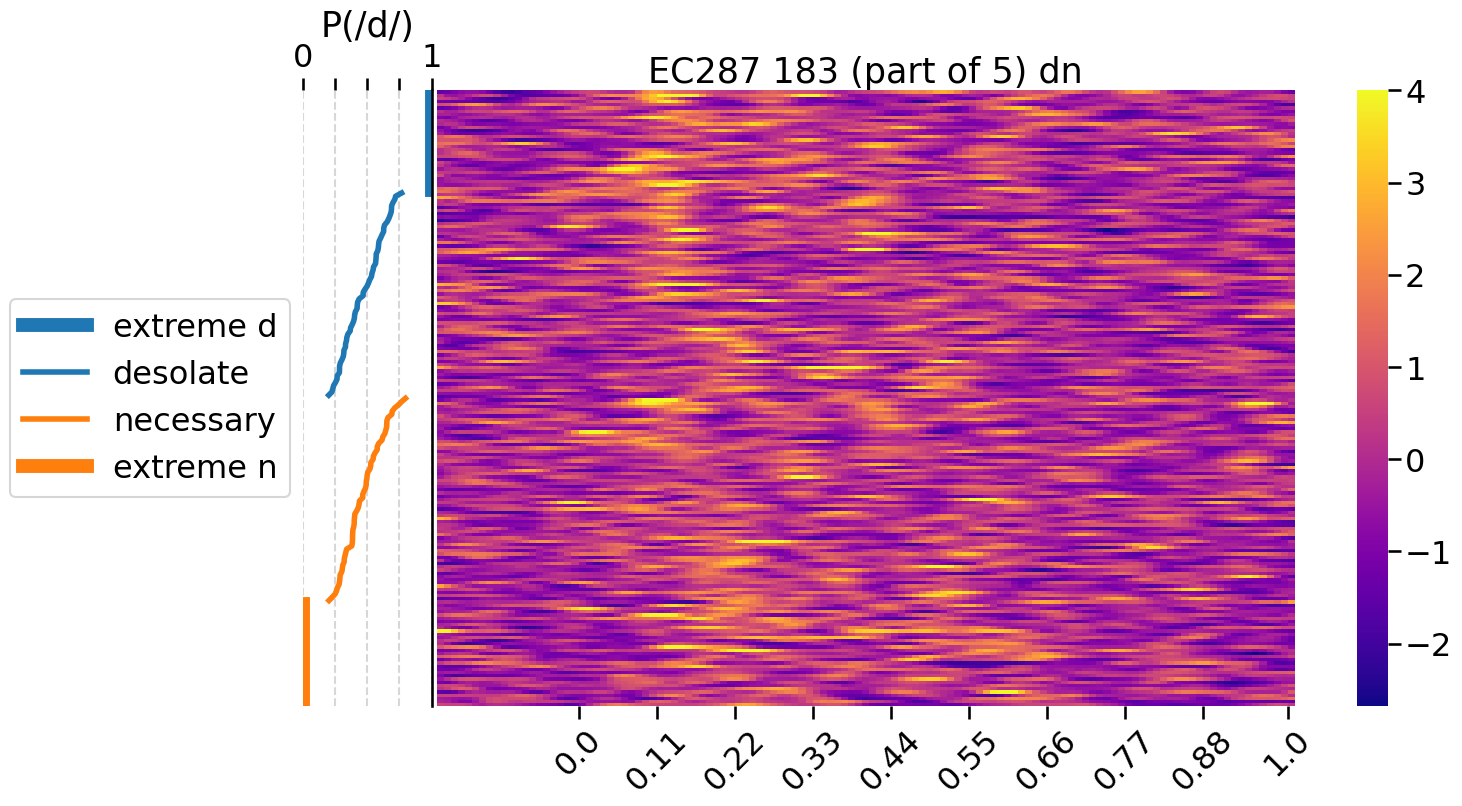

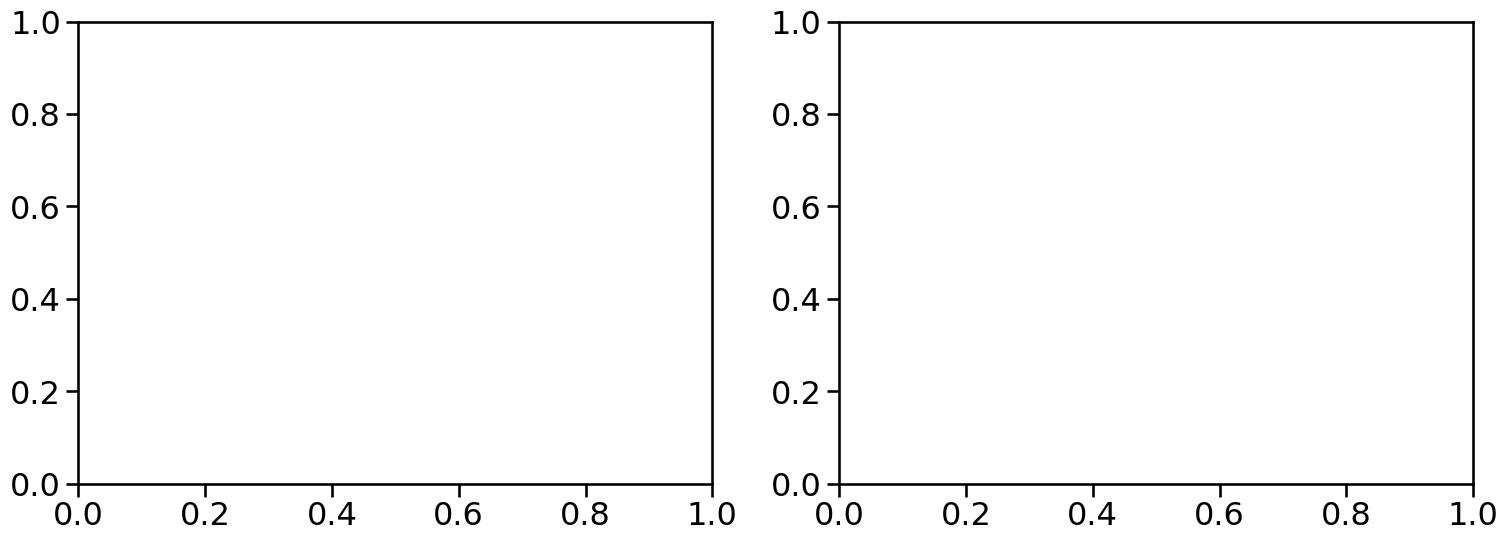

In [85]:
from matplotlib.backends.backend_pdf import PdfPages

with PdfPages(f"{outdir}/causal4_A_rasters.pdf") as pdf:
    for population in tqdm(top_A.index):
        subject, phoneme_pair, population = population.split("_")
        figs = plot_A_raster(subject, phoneme_pair, population,
                             rasterized=True,
                             height=8,
                             clip_zscore=(-4, 4),
                             parameter_cache=parameter_cache)
        
        timit_figs = []
        for el in populations_dict[subject, phoneme_pair, population]["electrodes_a"]:
            try:
                f = viz.timit_subplots(subject, el, list(phoneme_pair.upper()),
                                       timit_epoch_sources, timit_bounds_dict=timit_bounds,
                                       cell_height=6, cell_aspect=1.5)
            except Exception as e:
                print(f"Error plotting TIMIT for {subject} {el + 1} ({phoneme_pair}): {e}")
                continue
            f.suptitle(f"{subject} {el + 1} ({phoneme_pair})")
            timit_figs.append(f)

        for raster_fig, timit_fig in zip(figs, timit_figs):
            raster_fig.tight_layout()
            pdf.savefig(raster_fig, bbox_inches='tight')
            plt.close(raster_fig)

            timit_fig.tight_layout()
            pdf.savefig(timit_fig, bbox_inches='tight')
            plt.close(timit_fig)

## Confusion matrix

<Axes: ylabel='subject-phoneme_pair-population'>

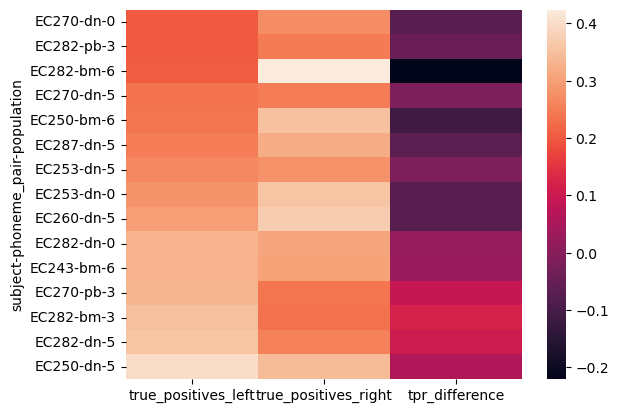

In [188]:
all_tprs = []
for ((subject, phoneme_pair, population), repeat), result in all_results_meta.items():
    p_left_phoneme = result.p_left_phoneme
    y_true = result.test_trial_metadata.categorical_acoustic_cue.map({-1: 1, 1: 0})
    true_positives_left = (y_true == 1) & (p_left_phoneme > 0.5)
    true_positives_right = (y_true == 0) & (p_left_phoneme < 0.5)
    all_tprs.append((subject, phoneme_pair, population,
                     f"{subject}_{phoneme_pair}_{population}",
                     repeat,
                    true_positives_left.mean(),
                    true_positives_right.mean(),
                    true_positives_left.mean() - true_positives_right.mean()))
all_tprs = pd.DataFrame(all_tprs, columns=[
    "subject", "phoneme_pair", "population", "site", "repeat",
    "true_positives_left", "true_positives_right", "tpr_difference"
])
sns.heatmap(all_tprs.groupby(["subject", "phoneme_pair", "population"])[["true_positives_left", "true_positives_right", "tpr_difference"]].mean().sort_values("true_positives_left"))

In [171]:
from io import StringIO
# sf = StringIO("""subject,phoneme_pair,population_A,mean,count
# EC282,bm,3,0.0,2
# EC270,dn,5,0.25,8
# EC253,dn,5,0.3333333333333333,6
# EC282,dn,0,0.5,4
# EC270,dn,0,0.75,4
# EC253,dn,0,0.7857142857142857,14
# EC282,bm,6,1.0,2
# EC282,dn,5,1.0,3""")
sf = StringIO("""subject,phoneme_pair,population_A,mean,count
EC282,bm,3,0.0,2
EC270,dn,5,0.2222222222222222,9
EC250,dn,5,0.25,4
EC287,dn,5,0.3,10
EC253,dn,5,0.3333333333333333,6
EC243,bm,6,0.42857142857142855,7
EC282,dn,0,0.5,4
EC282,pb,3,0.5,6
EC270,dn,0,0.6,5
EC260,dn,5,0.6153846153846154,13
EC270,pb,3,0.6666666666666666,6
EC250,bm,6,0.7142857142857143,14
EC253,dn,0,0.7857142857142857,14
EC282,bm,6,1.0,2
EC282,dn,5,1.0,3""")
exclusive_Bs = pd.read_csv(sf)

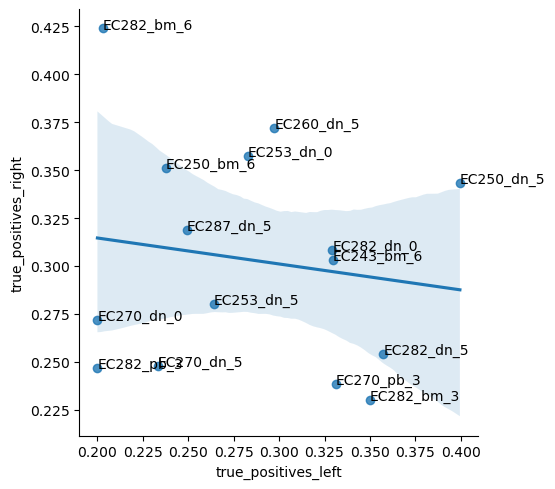

In [196]:
tpr_summary = all_tprs.groupby(["subject", "phoneme_pair", "population", "site"])[["tpr_difference", "true_positives_left", "true_positives_right"]].mean()
sns.lmplot(data=tpr_summary.reset_index(),
                x="true_positives_left", y="true_positives_right")
# label points
for label, row in tpr_summary.iterrows():
    plt.text(row.true_positives_left, row.true_positives_right, label[-1], fontsize=10)


PearsonRResult(statistic=0.4305049010984109, pvalue=0.10918304018050032)


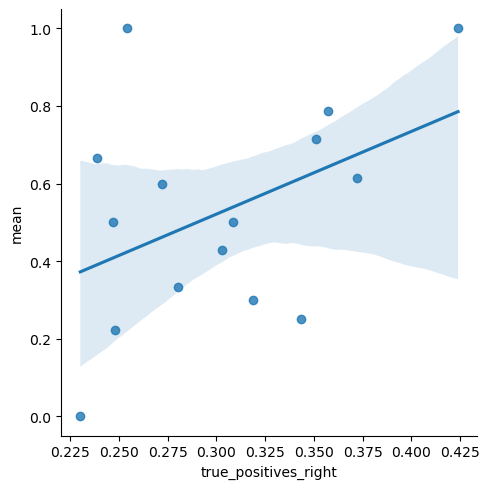

In [199]:
tpr_relation_df = pd.merge(tpr_summary, exclusive_Bs.astype({"population_A": str}), left_on=["subject", "phoneme_pair", "population"], right_on=["subject", "phoneme_pair", "population_A"], how="left")
print(pearsonr(tpr_relation_df["true_positives_right"], tpr_relation_df["mean"]))
sns.lmplot(data=tpr_relation_df,
                x="true_positives_right", y="mean")

In [118]:
all_md = []
for ((subject, phoneme_pair, population), repeat), result in all_results_meta.items():
    md = result.test_trial_metadata.assign(
        subject=subject,
        phoneme_pair=phoneme_pair,
        population=population,
        repeat=repeat,
        site=f"{subject}_{phoneme_pair}_{population}",
    )
    md["p_left_phoneme"] = result.p_left_phoneme
    all_md.append(md)
all_md = pd.concat(all_md).reset_index(drop=True)

In [133]:
all_md.groupby(["site", "categorical_acoustic_cue"]).p_left_phoneme.std().unstack().sort_values(1)

categorical_acoustic_cue,-1,1
site,,
EC282_bm_3,0.071184,0.072339
EC253_dn_5,0.118758,0.123930
EC282_pb_3,0.121422,0.128240
EC270_pb_3,0.142221,0.140195
EC270_dn_0,0.122305,0.142012
EC260_dn_5,0.174208,0.142842
EC243_bm_6,0.161156,0.147548
EC287_dn_5,0.168057,0.172038
EC270_dn_5,0.183225,0.178995


<Axes: xlabel='categorical_acoustic_cue', ylabel='site'>

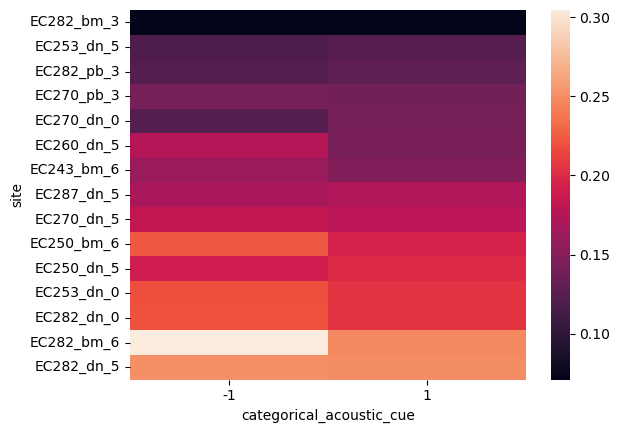

In [132]:
sns.heatmap(all_md.groupby(["site", "categorical_acoustic_cue"]).p_left_phoneme.std().unstack().sort_values(1))

In [134]:
# compute d-prime per site
def compute_d_prime(md: pd.DataFrame) -> pd.Series:
    """
    Compute d-prime for each site in the metadata DataFrame.
    """
    left_phoneme = md.p_left_phoneme[md.categorical_acoustic_cue == -1]
    right_phoneme = md.p_left_phoneme[md.categorical_acoustic_cue == 1]
    return (left_phoneme.mean() - right_phoneme.mean()) / \
              np.sqrt(0.5 * (left_phoneme.var() + right_phoneme.var()))
site_d_prime = all_md.groupby("site").apply(compute_d_prime).rename("d_prime")
site_order = site_d_prime.sort_values(ascending=False).index

/tmp/ipykernel_1612163/3223454021.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  site_d_prime = all_md.groupby("site").apply(compute_d_prime).rename("d_prime")


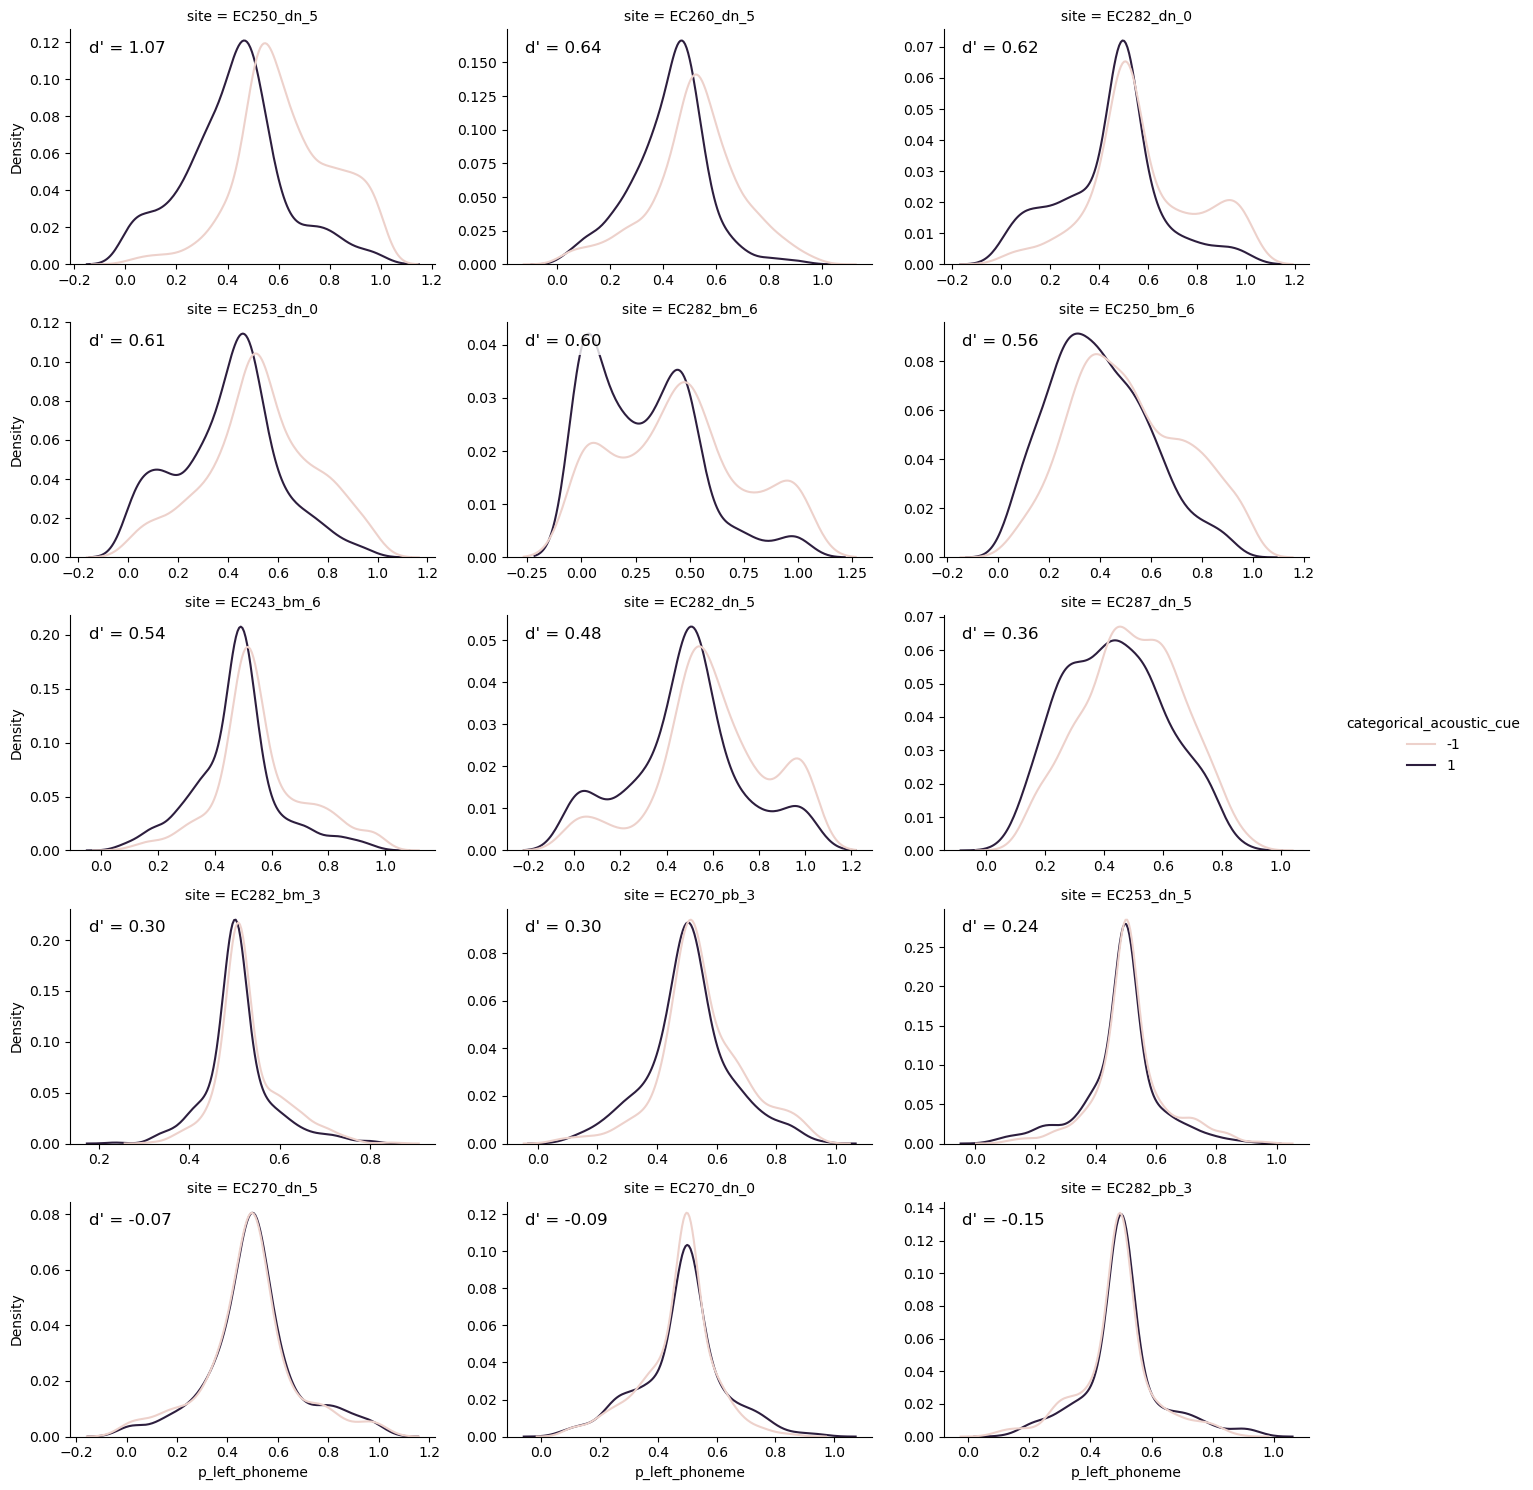

In [138]:
g = sns.displot(data=all_md, x="p_left_phoneme", kind="kde", hue="categorical_acoustic_cue",
         col="site", col_order=site_order, col_wrap=3, height=3, aspect=1.5,
         facet_kws={"sharex": False, "sharey": False})

# render the d-prime values on the plot
for ax, site in zip(g.axes.flat, site_order):
    d_prime = site_d_prime[site]
    ax.text(0.05, 0.95, f"d' = {d_prime:.2f}", transform=ax.transAxes,
            fontsize=12, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

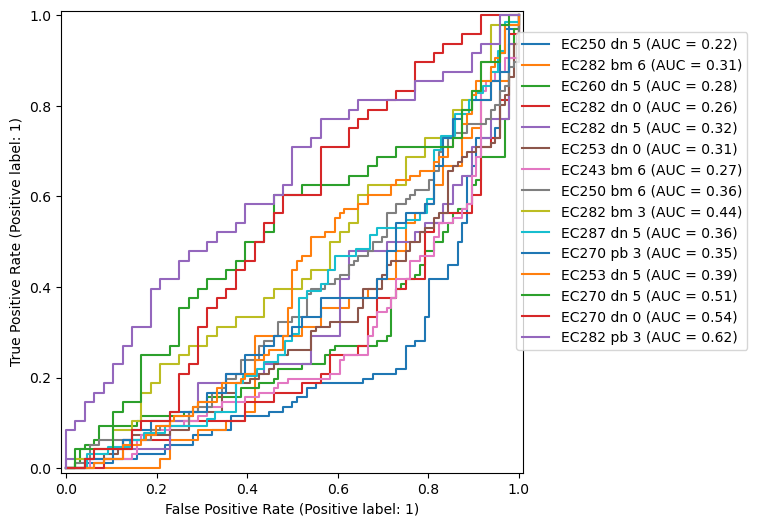

In [106]:
# n_cols = 3
# n_rows = int(np.ceil(len(top_A) / n_cols))
# fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4),
#                         gridspec_kw={"hspace": 0.3, "wspace": 0.3})
# axs = axs.flatten()
f, ax = plt.subplots(figsize=(8, 6))
for population in top_A.index:
    subject, phoneme_pair, population = population.split("_")
    plot_meta = all_results_meta[(subject, phoneme_pair, population), 0]
    RocCurveDisplay.from_predictions(
        plot_meta.test_trial_metadata.categorical_acoustic_cue.map({-1: 1, 1: 0}),
        1 - plot_meta.p_left_phoneme,
        ax=ax,
        name=f"{subject} {phoneme_pair} {population}",
    )

ax.legend(loc="lower right", bbox_to_anchor=(1.5, 0.25))

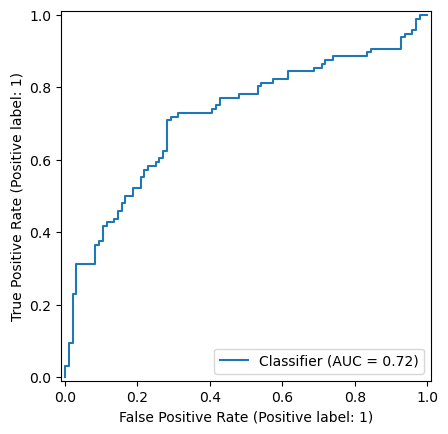

In [ ]:
# prec/recall curve
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay, \
    roc_curve, RocCurveDisplay
meta_key = ("EC260", "dn", '5')
avg_roc_curve = np.mean([roc_curve(
    plot_meta.test_trial_metadata.categorical_acoustic_cue.map({-1: 1, 1: 0}),
    all_results_meta[meta_key, repeat].p_left_phoneme,
    drop_intermediate=False)
    for repeat in range(n_repeats)],  # average over repeats
    axis=0)

RocCurveDisplay()

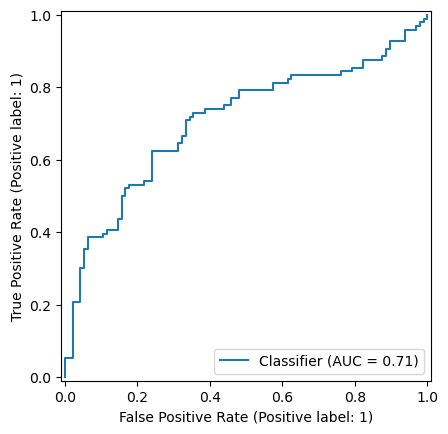

In [88]:
# prec/recall curve
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay, \
    roc_curve, RocCurveDisplay
plot_meta = all_results_meta[("EC260", "dn", '5'), 5]
p_left_phoneme = plot_meta.p_left_phoneme
RocCurveDisplay.from_predictions(
    plot_meta.test_trial_metadata.categorical_acoustic_cue.map({-1: 1, 1: 0}),
    p_left_phoneme)

0.3134353931705977
0.6359468234064156
0.2422658339436177
0.10312090410250209


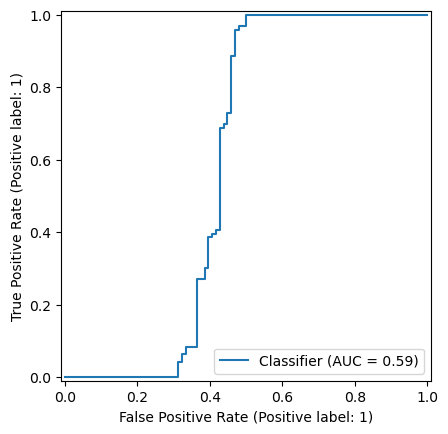

In [81]:
# DEV make some extreme versions
# low noise on right, high noise on left
preds = np.zeros_like(p_left_phoneme)
preds[plot_meta.test_trial_metadata.categorical_acoustic_cue == -1] = \
    np.minimum(1, ((np.random.randn((plot_meta.test_trial_metadata.categorical_acoustic_cue == 1).sum()) - 0.5) * 0.8 + 0.9))
preds[plot_meta.test_trial_metadata.categorical_acoustic_cue == 1] = \
    np.maximum(0, ((np.random.randn((plot_meta.test_trial_metadata.categorical_acoustic_cue == 1).sum()) - 0.5) * 0.1 + 0.3))
print(preds[plot_meta.test_trial_metadata.categorical_acoustic_cue == -1].mean())
print(preds[plot_meta.test_trial_metadata.categorical_acoustic_cue == -1].std())
print(preds[plot_meta.test_trial_metadata.categorical_acoustic_cue == 1].mean())
print(preds[plot_meta.test_trial_metadata.categorical_acoustic_cue == 1].std())
RocCurveDisplay.from_predictions(
    plot_meta.test_trial_metadata.categorical_acoustic_cue.map({-1: 0, 1: 1}),
    1 - preds)

0.8449639992758456
0.09947339167584929
0.291424686873079
0.4611042838470413


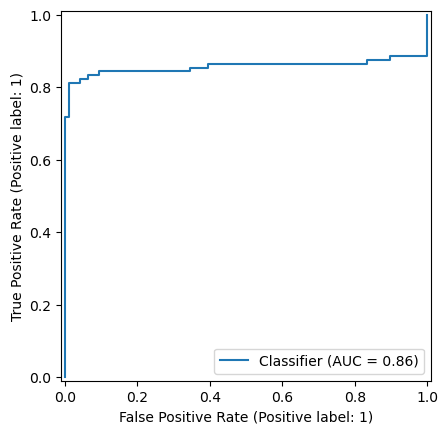

In [82]:
# DEV make some extreme versions
# high noise on right, low noise on left
preds = np.zeros_like(p_left_phoneme)
preds[plot_meta.test_trial_metadata.categorical_acoustic_cue == -1] = \
    np.minimum(1, ((np.random.randn((plot_meta.test_trial_metadata.categorical_acoustic_cue == 1).sum()) - 0.5) * 0.1 + 0.9))
preds[plot_meta.test_trial_metadata.categorical_acoustic_cue == 1] = \
    np.maximum(0, ((np.random.randn((plot_meta.test_trial_metadata.categorical_acoustic_cue == 1).sum()) - 0.5) * 0.8 + 0.3))
print(preds[plot_meta.test_trial_metadata.categorical_acoustic_cue == -1].mean())
print(preds[plot_meta.test_trial_metadata.categorical_acoustic_cue == -1].std())
print(preds[plot_meta.test_trial_metadata.categorical_acoustic_cue == 1].mean())
print(preds[plot_meta.test_trial_metadata.categorical_acoustic_cue == 1].std())
RocCurveDisplay.from_predictions(
    plot_meta.test_trial_metadata.categorical_acoustic_cue.map({-1: 0, 1: 1}),
    1 - preds)

In [29]:
p_left_phoneme = all_results_meta[("EC260", "dn", '5'), 0].p_left_phoneme
confusion_matrices = {}
for (subject, phoneme_pair, population), result in all_results_meta.items():
    if result.p_left_phoneme is None:
        continue
    confusion_matrices[(subject, phoneme_pair, population)] = confusion_matrix(
        result.test_trial_metadata.left_phoneme,
        result.test_trial_metadata.predicted_left_phoneme,
        labels=result.test_trial_metadata.left_phoneme.unique(),
    )

array([0.76710554, 0.75403084, 0.51294976, 0.55218679, 0.4693235 ,
       0.60155202, 0.49597801, 0.6720474 , 0.46234299, 0.59860901,
       0.46140776, 0.59655145, 0.51492647, 0.610238  , 0.50641109,
       0.81424306, 0.66699512, 0.60316943, 0.54656587, 0.52727335,
       0.48548326, 0.42783455, 0.43035499, 0.57903434, 0.49368951,
       0.44210268, 0.53633824, 0.74454248, 0.50862733, 0.51779581,
       0.48202018, 0.38460869, 0.43789236, 0.49762053, 0.55169227,
       0.42663252, 0.63433056, 0.74473509, 0.35471907, 0.3629325 ,
       0.37970859, 0.47533275, 0.69250472, 0.40886215, 0.51608385,
       0.38600589, 0.59307391, 0.55897704, 0.47595859, 0.46304398,
       0.44239634, 0.53255249, 0.57232409, 0.40986727, 0.51362868,
       0.50618907, 0.48521315, 0.61073589, 0.73691406, 0.60259255,
       0.62134053, 0.38923281, 0.38722621, 0.38199394, 0.25040865,
       0.30192628, 0.23785501, 0.25107097, 0.22430128, 0.53671565,
       0.34321524, 0.26344753, 0.36205948, 0.27218523, 0.31031

In [216]:
epochs["EC250"].metadata.groupby(["phoneme_pair", "resampled", "word_end"]).size()

phoneme_pair  resampled  word_end  
bm            1.0        bountiful     24
                         mountains     24
              2.0        bountiful     24
                         mountains     24
              3.0        bountiful     24
                         mountains     24
              4.0        bountiful     24
                         mountains     24
              5.0        bountiful     24
                         mountains     24
              6.0        bountiful     24
                         mountains     24
dn            1.0        desolate      24
                         necessary     24
              2.0        desolate      24
                         necessary     24
              3.0        desolate      24
                         necessary     24
              4.0        desolate      24
                         necessary     24
              5.0        desolate      24
                         necessary     24
              6.0        desolate      2

In [227]:
{s: epochs_i.metadata.groupby(["phoneme_pair", "resampled", "word_end"]).size().agg(["min", "max"])
 for s, epochs_i in epochs.items()}

{'EC278': min    32
 max    32
 dtype: int64,
 'EC270': min    12
 max    12
 dtype: int64,
 'EC253': min    24
 max    24
 dtype: int64,
 'EC279': min    24
 max    24
 dtype: int64,
 'EC260': min    24
 max    24
 dtype: int64,
 'EC243': min    24
 max    24
 dtype: int64,
 'EC250': min    24
 max    24
 dtype: int64,
 'EC287': min    16
 max    16
 dtype: int64,
 'EC248': min    24
 max    24
 dtype: int64,
 'EC282': min    12
 max    12
 dtype: int64}

In [225]:
{s: epochs_i.metadata['TDT Block'].nunique()
 for s, epochs_i in epochs.items()}

{'EC278': 8,
 'EC270': 3,
 'EC253': 6,
 'EC279': 6,
 'EC260': 6,
 'EC243': 6,
 'EC250': 6,
 'EC287': 4,
 'EC248': 6,
 'EC282': 3}

## Is B predictive of behavior?

In [21]:
searchlight_results_df

,long_name,type,roi,speech_responsive,corr_left,p_val_left,corr_right,p_val_right,control_corr_left,control_p_val_left,...,left_is_best,p_val_min,control_p_val_min,behavior_roc_auc,counterfactual_spearmanr,counterfactual_spearmanr_list,counterfactual_spearmanr_z,counterfactual_test_z,counterfactual_test_p,counterfactual_n
74,Temporal75,grid,superiortemporal,True,0.164134,0.264954,-0.629614,0.000002,0.079360,0.591839,...,False,0.000002,0.402045,0.595155,-0.062671,"[0.16478506296135473, -0.14513677811550152, -0...",-0.063834,-5.118007,7.114100e-07,205
196,Inferior69,grid,superiortemporal,True,0.425095,0.000016,0.010011,0.922882,-0.089097,0.388000,...,True,0.000016,0.388000,0.498584,0.031824,"[0.09998711663282378, 0.009920137698414842, 0....",0.032153,3.958697,1.380904e-04,105
75,Temporal76,grid,superiortemporal,True,0.106166,0.472644,-0.574685,0.000019,-0.021521,0.884561,...,False,0.000019,0.338310,0.584821,-0.062545,"[-0.028006947459835, 0.05644811115935735, 0.15...",-0.063461,-4.672717,5.392186e-06,205
113,Temporal114,grid,postcentral,True,0.526596,0.000121,-0.014980,0.919505,-0.107606,0.466623,...,True,0.000121,0.466623,0.250000,0.043042,"[0.10974815458098132, 0.017368649587494574, 0....",0.043610,4.093935,5.671893e-05,260
44,Temporal45,grid,superiortemporal,True,-0.525510,0.000125,-0.085323,0.564203,-0.133163,0.366905,...,True,0.000125,0.366905,0.415757,0.037089,"[-0.1744463742943986, -0.20733825445071646, -0...",0.037456,-4.001599,8.217925e-05,260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119,Temporal120,grid,superiortemporal,True,0.019865,0.893389,-0.370278,0.009583,0.217903,0.136798,...,False,0.009583,0.643159,0.452381,-0.074443,"[-0.01693443334780721, -0.12592270950933565, -...",-0.075876,-2.475647,1.411407e-02,205
203,PosteriorGrid76,grid,postcentral,True,0.090762,0.379155,0.262724,0.009709,0.021518,0.835157,...,False,0.009709,0.339635,0.561904,0.005961,"[-0.205604537380151, 0.0012688332892707799, -0...",0.006075,2.387931,1.766074e-02,260
101,AnteriorGrid102,grid,parsopercularis,True,0.262493,0.009775,-0.113090,0.272615,-0.145245,0.157962,...,True,0.009775,0.157962,0.409784,0.033808,"[0.023560310055840725, 0.19547894456830836, 0....",0.034122,2.135373,3.366892e-02,260
89,Temporal90,grid,superiortemporal,True,0.369301,0.009790,-0.356817,0.012793,-0.076669,0.604498,...,True,0.009790,0.604498,0.847826,0.053626,"[-0.09216239687364307, 0.005644811115935735, 0...",0.054067,3.182079,3.346861e-02,5


In [208]:
behavior_clf_from_B_results = []
n_permutations = 100
metric = "roc_auc"
for (subject, phoneme_pair), rows in tqdm(searchlight_results_df.groupby(["subject", "phoneme_pair"])):
    all_data = []
    prev_Y_i = None
    prev_epoch_idxs = None
    for _, row in rows.iterrows():
        data_key = "window_data_left_mean" if row.left_is_best else "window_data_right_mean"
        activations_i = searchlight_electrode_activations[row.subject, row.phoneme_pair, row.population_A, row.window_start_samp, row.window_end_samp]

        epoch_idxs = activations_i["metadata"].index
        data_i = activations_i[data_key][:, row.electrode_idx]
        mask_i = activations_i["mask_left"] if row.left_is_best else ~activations_i["mask_left"]
        control_i = activations_i["control_predictor"][mask_i].values
        assert data_i.shape[0] == control_i.shape[0], (data_i.shape, control_i.shape)

        data_i -= data_i.mean(axis=0, keepdims=True)
        control_i -= control_i.mean(axis=0, keepdims=True)

        if prev_epoch_idxs is not None:
            assert np.array_equal(epoch_idxs, prev_epoch_idxs), (epoch_idxs.shape, prev_epoch_idxs.shape)
        prev_epoch_idxs = epoch_idxs

        Y_i = activations_i["metadata"].behavior_dummy_forced
        if prev_Y_i is not None:
            assert np.array_equal(Y_i, prev_Y_i), (Y_i.shape, prev_Y_i.shape)
        prev_Y_i = Y_i.copy()

        Y_i = Y_i[mask_i].values
        
        all_data.append(data_i)

    from sklearn.linear_model import LogisticRegression
    from sklearn.model_selection import cross_val_score, StratifiedKFold
    
    X = np.stack(all_data).T

    # if we only have one class, skip
    if len(np.unique(Y_i)) < 2:
        print(f"Skipping {subject} {phoneme_pair} {row.population_A} due to single class in Y_i")
        continue

    val_scores = cross_val_score(
        LogisticRegression(max_iter=1000, random_state=43, C=0.1, class_weight="balanced"),
        np.concatenate([control_i[:, np.newaxis], X], axis=1), Y_i,
        cv=StratifiedKFold(n_splits=2, shuffle=True, random_state=43),
        scoring=metric, n_jobs=-1
    )
    control_val_scores = cross_val_score(
        LogisticRegression(max_iter=1000, random_state=43, C=0.1, class_weight="balanced"),
        control_i[:, np.newaxis], Y_i,
        cv=StratifiedKFold(n_splits=2, shuffle=True, random_state=43),
        scoring=metric, n_jobs=-1
    )

    improvements = val_scores - control_val_scores

    # permutation baseline
    permuted_scores = []
    for _ in range(n_permutations):
        X_perm = X.copy()
        np.random.shuffle(X_perm)

        permuted_val_scores = cross_val_score(
            LogisticRegression(max_iter=1000, random_state=43, C=0.1, class_weight="balanced"),
            np.concatenate([control_i[:, np.newaxis], X_perm], axis=1), Y_i,
            cv=StratifiedKFold(n_splits=2, shuffle=True, random_state=43),
            scoring=metric, n_jobs=-1
        )
        permuted_scores.append(permuted_val_scores)
    permuted_scores = np.array(permuted_scores)
    permuted_improvements = permuted_scores - control_val_scores[np.newaxis, :]

    model_permuted_improvements = improvements - np.maximum(permuted_improvements.mean(axis=0), 0)

    behavior_clf_from_B_results.append({
        "subject": subject,
        "phoneme_pair": phoneme_pair,
        "population_A": row.population_A,
        "roc_auc_val": val_scores.mean(),
        "roc_auc_std": val_scores.std(),
        "roc_auc_control_val": control_val_scores.mean(),
        "roc_auc_control_std": control_val_scores.std(),
        "improvement": improvements.mean(),
        "improvement_std": improvements.std(),
        "permuted_scores_mean": permuted_scores.mean(axis=0).mean(),
        "permuted_scores_std": permuted_scores.std(axis=0).mean(),
        "permuted_improvement": permuted_improvements.mean(),
        "permuted_improvement_std": permuted_improvements.std(),
        "model_permuted_improvement": model_permuted_improvements.mean(),
        "model_permuted_improvement_std": model_permuted_improvements.std(),
    })

  0%|          | 0/11 [00:00<?, ?it/s]

Skipping EC282 pb 3 due to single class in Y_i


In [209]:
behavior_clf_from_B_results_df = pd.DataFrame(behavior_clf_from_B_results)
behavior_clf_from_B_results_df.sort_values("improvement", ascending=False)

,subject,phoneme_pair,population_A,roc_auc_val,roc_auc_std,roc_auc_control_val,roc_auc_control_std,improvement,improvement_std,permuted_scores_mean,permuted_scores_std,permuted_improvement,permuted_improvement_std,model_permuted_improvement,model_permuted_improvement_std
6,EC270,pb,3,0.521739,0.000000,0.239130,0.108696,0.282609,0.108696,0.303043,0.217241,0.063913,0.230595,0.213913,0.040000
9,EC287,dn,5,0.815079,0.029365,0.795370,0.045370,0.019709,0.016005,0.751408,0.074014,-0.043962,0.083321,0.019709,0.016005
3,EC253,dn,0,0.949555,0.003258,0.934332,0.013036,0.015222,0.009778,0.912368,0.026661,-0.021965,0.026794,0.015222,0.009778
7,EC282,bm,3,0.975000,0.025000,0.962500,0.037500,0.012500,0.012500,0.957661,0.026197,-0.004839,0.028897,0.012500,0.012500
4,EC260,dn,5,0.979130,0.012174,0.969565,0.003478,0.009565,0.008696,0.968113,0.011093,-0.001452,0.011094,0.009565,0.008696
8,EC282,dn,5,0.928571,0.023810,0.928571,0.000000,0.000000,0.023810,0.929683,0.043043,0.001111,0.043136,-0.001587,0.025397
1,EC250,bm,6,0.949107,0.018750,0.950893,0.022321,-0.001786,0.003571,0.950848,0.012988,-0.000045,0.013112,-0.002616,0.002741
2,EC250,dn,5,0.973965,0.004057,0.979781,0.002858,-0.005816,0.006915,0.979768,0.010932,-0.000013,0.010943,-0.006001,0.007100
0,EC243,bm,6,0.781735,0.079376,0.794763,0.098756,-0.013028,0.019380,0.773658,0.032948,-0.021105,0.038551,-0.013028,0.019380
5,EC270,dn,5,0.653860,0.050685,0.702652,0.035985,-0.048791,0.014701,0.608775,0.165800,-0.093876,0.167606,-0.048791,0.014701


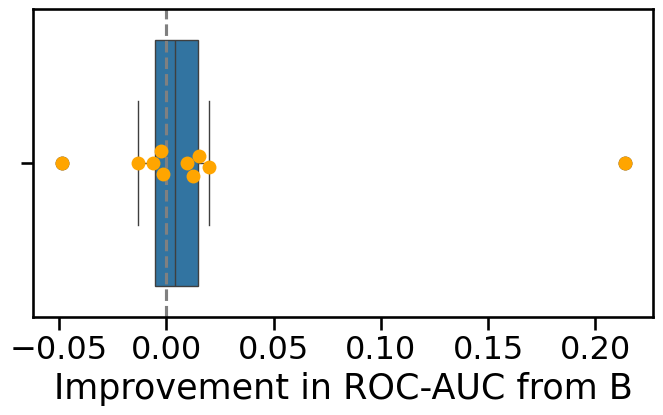

In [210]:
f, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=behavior_clf_from_B_results_df, x="model_permuted_improvement", ax=ax)
ax = sns.swarmplot(data=behavior_clf_from_B_results_df, x="model_permuted_improvement", s=10, color="orange")
ax.set_xlabel("Improvement in ROC-AUC from B")
ax.axvline(0, linestyle="--", color="gray")

Text(0.5, -9.916666666666673, 'Baseline ROC-AUC')

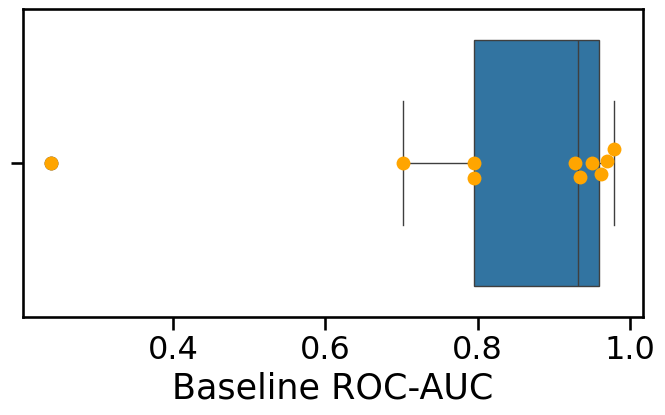

In [211]:
f, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=behavior_clf_from_B_results_df, x="roc_auc_control_val", ax=ax)
ax = sns.swarmplot(data=behavior_clf_from_B_results_df, x="roc_auc_control_val", s=10, color="orange", ax=ax)
ax.set_xlabel("Baseline ROC-AUC")

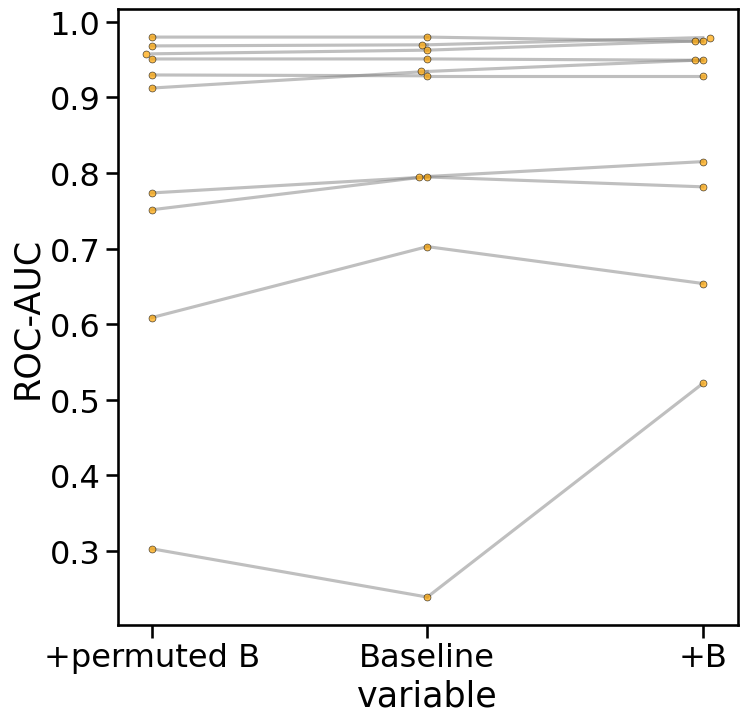

In [212]:
plot_behavior_prediction_df = behavior_clf_from_B_results_df.melt(
    id_vars=["subject", "phoneme_pair", "population_A"],
    # value_vars=["improvement", "permuted_improvement"]
    value_vars=["roc_auc_val", "roc_auc_control_val", "permuted_scores_mean"]
)
plot_behavior_prediction_df["variable"] = plot_behavior_prediction_df.variable.map({
    "roc_auc_val": "+B",
    "roc_auc_control_val": "Baseline",
    "permuted_scores_mean": "+permuted B",
})

f, ax = plt.subplots(figsize=(8, 8))
# ax = sns.boxplot(data=plot_behavior_prediction_df, y="value", x="variable",
#             order=["+permuted B", "Baseline", "+B"],)
ax = sns.swarmplot(data=plot_behavior_prediction_df, y="value", x="variable",
              order=["+permuted B", "Baseline", "+B"], s=5,
              color="orange", alpha=0.7, edgecolor="black", linewidth=0.5)
ax.set_ylabel("ROC-AUC")

# draw spaghetti lines
for (subject, phoneme_pair, population_A), group in plot_behavior_prediction_df.groupby(["subject", "phoneme_pair", "population_A"]):
    group = group.set_index(["variable"]).value
    ax.plot([0, 1], [group["+permuted B"], group["Baseline"]], color="gray", alpha=0.5)
    ax.plot([1, 2], [group["Baseline"], group["+B"]], color="gray", alpha=0.5)

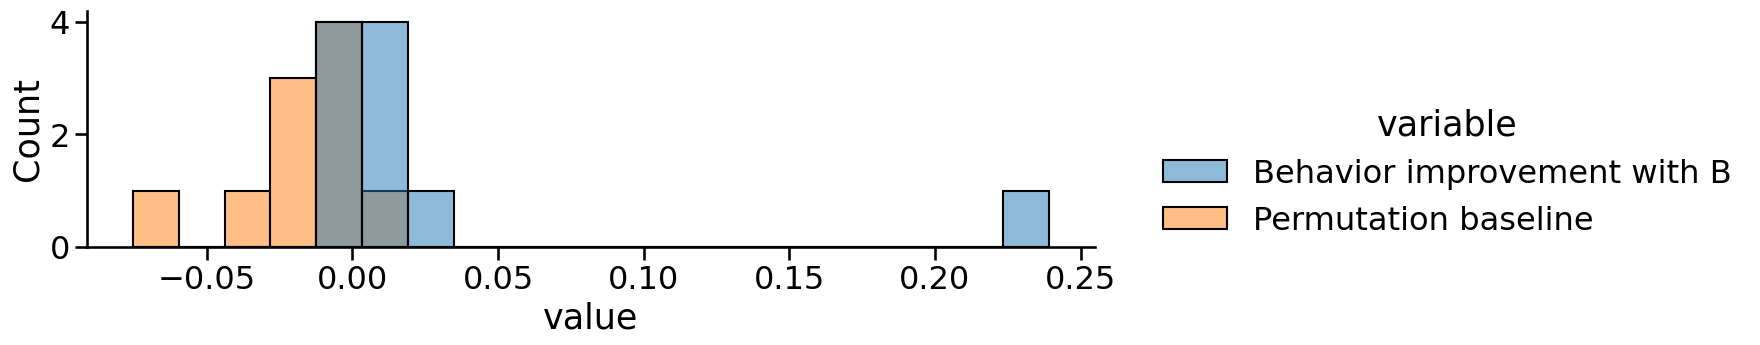

In [132]:
plot_behavior_prediction_df = behavior_clf_from_B_results_df.melt(
    id_vars=["subject", "phoneme_pair", "population_A"],
    value_vars=["improvement", "permuted_improvement"]
)
plot_behavior_prediction_df["variable"] = plot_behavior_prediction_df.variable.map({
    "improvement": "Behavior improvement with B",
    "permuted_improvement": "Permutation baseline"
})

sns.displot(data=plot_behavior_prediction_df,
            x="value", hue="variable", kind="hist", height=4, aspect=3)

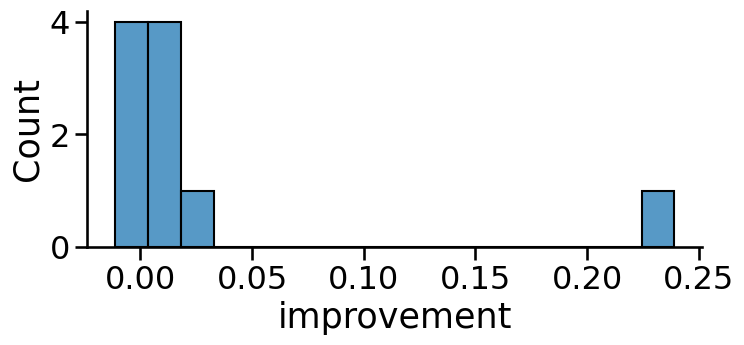

In [123]:
sns.displot(data=behavior_clf_from_B_results_df, x="improvement",#[behavior_clf_from_B_results_df.roc_auc_val > 0.5], x="improvement",
            height=4, aspect=2)

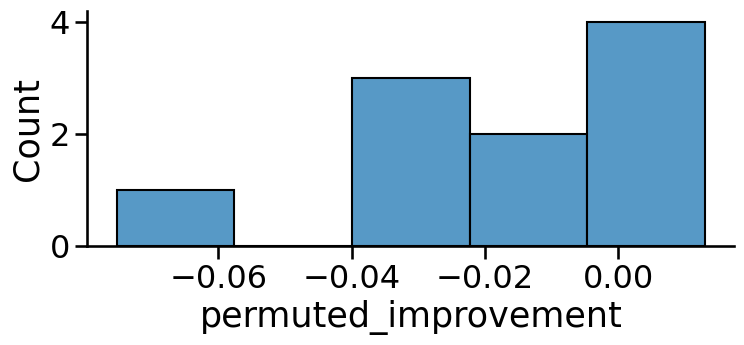

In [124]:
sns.displot(data=behavior_clf_from_B_results_df, x="permuted_improvement",#[behavior_clf_from_B_results_df.roc_auc_val > 0.5], x="improvement",
            height=4, aspect=2)

## Graph viz

In [220]:
results_df = pd.read_csv("outputs/causal4_searchlight/searchlight_results.csv", index_col=0)

In [221]:
results_df

,long_name,type,roi,speech_responsive,control_corr_left,control_corr_right,control_p_val_left,control_p_val_right,corr_left,corr_right,...,left_is_best,p_val_min,control_p_val_min,behavior_roc_auc,counterfactual_spearmanr,counterfactual_spearmanr_list,counterfactual_spearmanr_z,counterfactual_test_z,counterfactual_test_p,counterfactual_n
2500,Inferior69,grid,superiortemporal,True,-0.089097,-0.047070,0.388000,0.648820,0.417512,0.016522,...,True,0.000023,0.388000,0.498584,-0.002007,"[0.060987950525634514, 0.02891725410685947, 0....",-0.002057,6.175334,8.914537e-08,55
5173,AnteriorGrid54,grid,precentral,True,-0.022190,0.109606,0.830082,0.287757,0.397436,-0.092065,...,True,0.000061,0.830082,0.554566,0.001418,"[0.14921343777729262, 0.0020423812908501146, -...",0.001518,4.343640,3.393333e-05,100
2852,Superior37,grid,precentral,True,-0.099183,-0.125408,0.336332,0.223429,0.127116,0.381918,...,False,0.000123,0.223429,0.677544,-0.017325,"[0.11277807921866521, -0.05417797069994574, -0...",-0.017525,4.131137,1.448050e-02,5
5218,AnteriorGrid99,grid,superiortemporal,True,-0.134822,0.039337,0.190309,0.703558,0.374390,-0.276953,...,True,0.000171,0.190309,0.347768,0.051405,"[0.029156959421013758, 0.02055145996596518, 0....",0.051892,3.768441,2.792788e-04,100
2684,Superior125,grid,precentral,True,-0.042363,-0.053122,0.681939,0.607230,0.373114,-0.083736,...,True,0.000181,0.681939,0.384718,-0.026459,"[-0.072203569363726, 0.05231996651955152, 0.14...",-0.026667,4.677859,1.982196e-05,55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11422,Temporal95,grid,supramarginal,True,0.087430,0.010761,0.554588,0.942133,-0.137538,-0.369518,...,False,0.009743,0.942133,0.326087,-0.084108,"[-0.017042987407729047, -0.16728180633955708, ...",-0.084669,-4.294315,1.270265e-02,5
5030,PosteriorGrid39,grid,supramarginal,True,-0.047406,0.186263,0.646480,0.069213,0.076601,0.262032,...,False,0.009909,0.069213,0.548695,0.022098,"[0.09425161242483808, 0.22237152290085788, 0.1...",0.022318,1.918391,5.794246e-02,100
9643,Temporal108,grid,supramarginal,True,0.040352,-0.018831,0.785383,0.898911,0.240230,-0.368650,...,False,0.009930,0.898911,0.568700,0.005567,"[-0.10660008684324793, 0.08912288319583152, 0....",0.005706,-3.029699,2.764592e-03,205
4050,Inferior83,grid,precentral,True,-0.033621,0.129106,0.745031,0.209964,-0.057501,0.261951,...,False,0.009933,0.209964,0.564091,0.034036,"[-0.02573776669592392, 0.1269225320047894, -0....",0.034426,2.444202,1.561013e-02,160


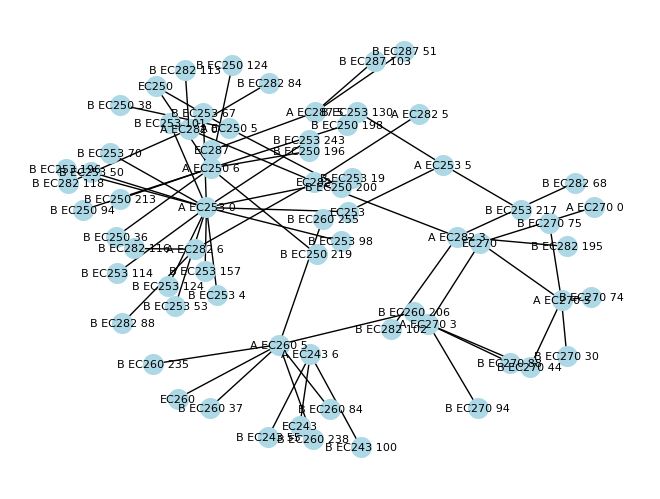

In [242]:
import networkx as nx
G = nx.Graph()

for subject in results_df.subject.unique():
    G.add_node(subject)

for population in populations_dict.values():
    subject = population["subject"]
    population_A = population["electrodes_a"]
    label = population["cluster_a"]
    G.add_node(" ".join(("A", subject, str(label))))
    G.add_edge(subject, " ".join(("A", subject, str(label))))

for _, row in results_df.head(50).iterrows():
    G.add_node(" ".join(("B", row.subject, str(row.electrode_idx))))
    G.add_edge(" ".join(("A", row.subject, str(row.population_A))), " ".join(("B", row.subject, str(row.electrode_idx))))

pos = nx.spring_layout(G, k=0.5)
nx.draw(G, pos, with_labels=True, node_size=200, node_color="lightblue", font_size=8, font_color="black")